In [1]:
import pandas as pd
import numpy as np

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample_sub = pd.read_csv("sample_submission.csv")

TARGET = "loan_paid_back"
print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head()

Train shape: (593994, 13)
Test shape: (254569, 12)


,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0


In [2]:
train.dtypes

id                        int64
annual_income           float64
debt_to_income_ratio    float64
credit_score              int64
loan_amount             float64
interest_rate           float64
gender                      str
marital_status              str
education_level             str
employment_status           str
loan_purpose                str
grade_subgrade              str
loan_paid_back          float64
dtype: object

In [3]:
print("Missing values (train):", train.isna().sum().sum())
print("Missing values (test):", test.isna().sum().sum())
print("Duplicate rows (train):", train.duplicated().sum())
print()
print(train[TARGET].value_counts(normalize=True))

Missing values (train): 0
Missing values (test): 0
Duplicate rows (train): 0

loan_paid_back
1.0    0.79882
0.0    0.20118
Name: proportion, dtype: float64


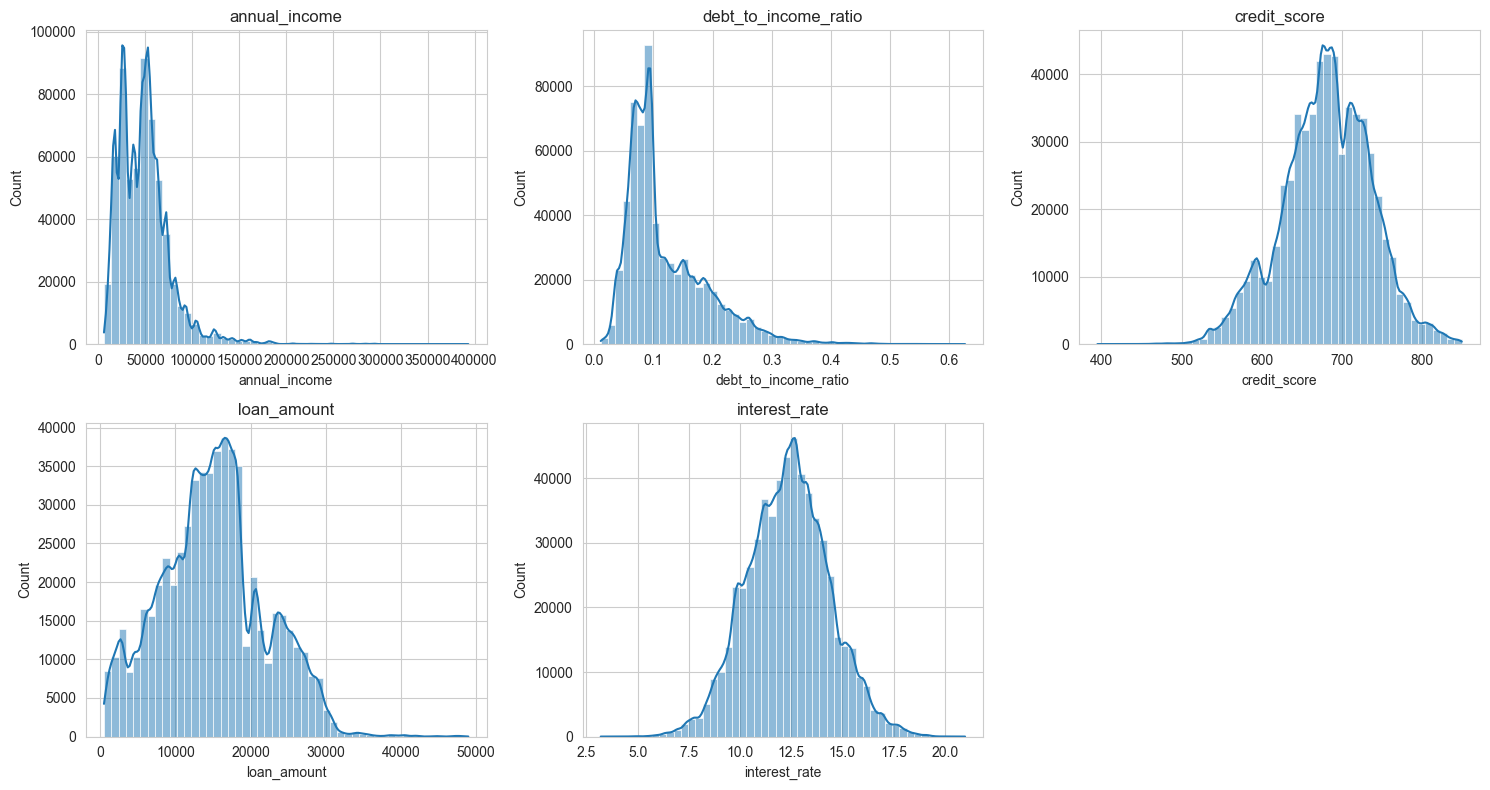

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

num_cols = ["annual_income", "debt_to_income_ratio", "credit_score", "loan_amount", "interest_rate"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(train[col], bins=50, kde=True, ax=ax)
    ax.set_title(col)
axes.flatten()[-1].axis("off")
plt.tight_layout()
plt.show()

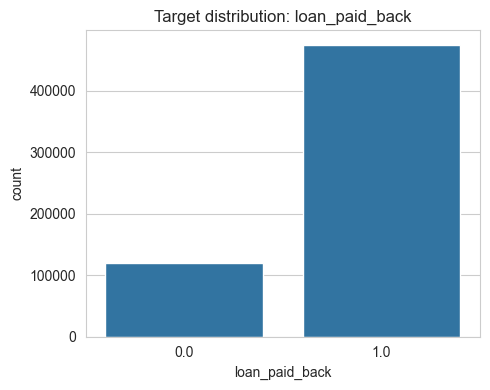

In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x=TARGET, data=train, ax=ax)
ax.set_title("Target distribution: loan_paid_back")
plt.tight_layout()
plt.show()

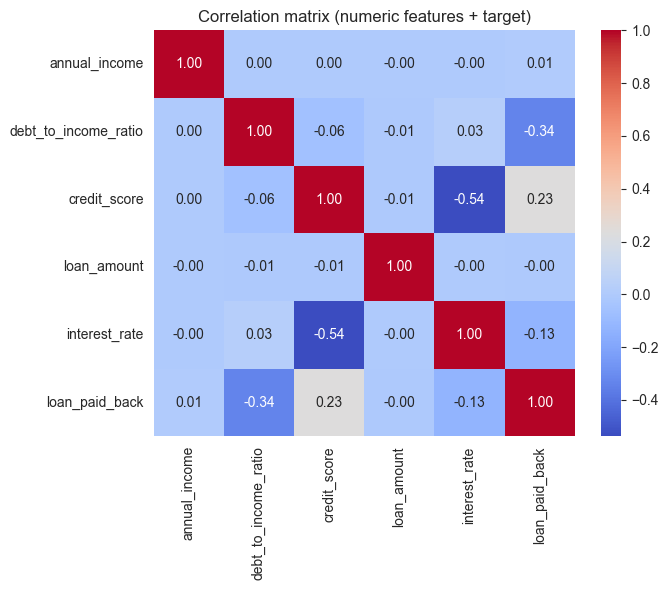

In [6]:
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(train[num_cols + [TARGET]].corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("Correlation matrix (numeric features + target)")
plt.tight_layout()
plt.show()

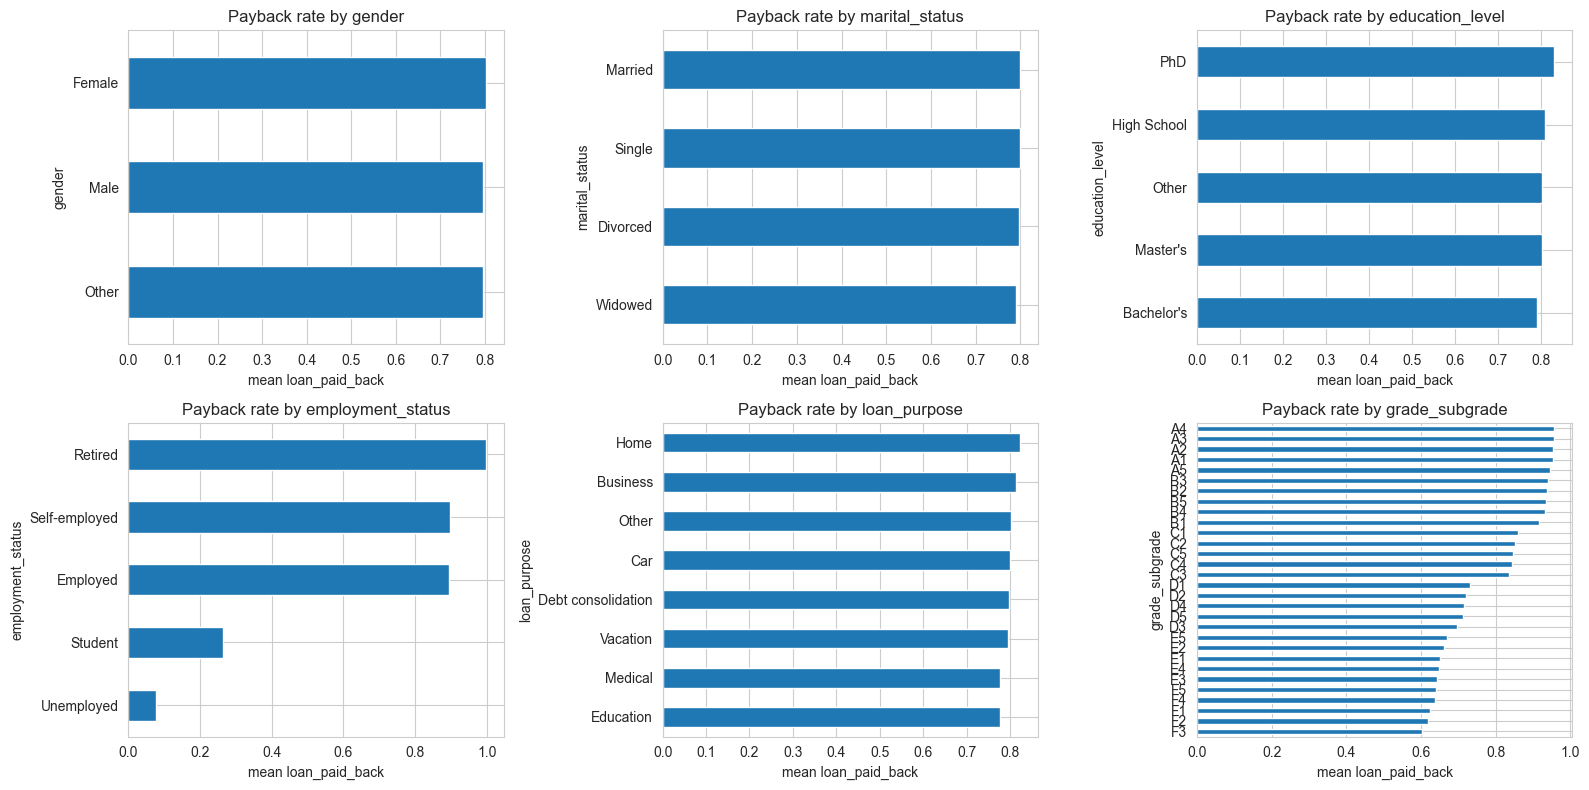

In [7]:
cat_cols = ["gender", "marital_status", "education_level", "employment_status", "loan_purpose", "grade_subgrade"]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), cat_cols):
    rate = train.groupby(col)[TARGET].mean().sort_values()
    rate.plot(kind="barh", ax=ax)
    ax.set_title(f"Payback rate by {col}")
    ax.set_xlabel("mean loan_paid_back")
plt.tight_layout()
plt.show()

In [8]:
train.groupby("grade_subgrade")[TARGET].mean().sort_index()

grade_subgrade
A1    0.952500
A2    0.952924
A3    0.955470
A4    0.957084
A5    0.944962
B1    0.916341
B2    0.937430
B3    0.940040
B4    0.931758
B5    0.934204
C1    0.860090
C2    0.851165
C3    0.836000
C4    0.843987
C5    0.846259
D1    0.731886
D2    0.720957
D3    0.695972
D4    0.714733
D5    0.713000
E1    0.652010
E2    0.662743
E3    0.641837
E4    0.649577
E5    0.669461
F1    0.624503
F2    0.617721
F3    0.604093
F4    0.637037
F5    0.639314
Name: loan_paid_back, dtype: float64

In [9]:
def engineer_features(df):
    df = df.copy()
    df["grade"] = df["grade_subgrade"].str[0]
    df["subgrade_num"] = df["grade_subgrade"].str[1].astype(int)
    df["loan_to_income"] = df["loan_amount"] / (df["annual_income"] + 1)
    df["income_per_dti"] = df["annual_income"] * (1 - df["debt_to_income_ratio"])
    df["est_monthly_debt"] = df["annual_income"] * df["debt_to_income_ratio"] / 12
    df["credit_score_bin"] = pd.cut(
        df["credit_score"], bins=[0, 580, 670, 740, 800, 900],
        labels=["poor", "fair", "good", "very_good", "exceptional"]
    ).astype(str)
    df["rate_to_score"] = df["interest_rate"] / (df["credit_score"] / 100)
    df["high_dti_flag"] = (df["debt_to_income_ratio"] > 0.3).astype(int)
    return df

from sklearn.preprocessing import OrdinalEncoder

train_fe = engineer_features(train)
test_fe = engineer_features(test)

cat_cols_fe = cat_cols + ["grade", "credit_score_bin"]
num_cols_fe = num_cols + ["subgrade_num", "loan_to_income", "income_per_dti",
                           "est_monthly_debt", "rate_to_score", "high_dti_flag"]

encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
train_fe[cat_cols_fe] = encoder.fit_transform(train_fe[cat_cols_fe].astype(str))
test_fe[cat_cols_fe] = encoder.transform(test_fe[cat_cols_fe].astype(str))

feature_cols = num_cols_fe + cat_cols_fe
X = train_fe[feature_cols]
y = train_fe[TARGET].astype(int)
X_test = test_fe[feature_cols]
print("Final feature count:", len(feature_cols))
print(feature_cols)

Final feature count: 19
['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate', 'subgrade_num', 'loan_to_income', 'income_per_dti', 'est_monthly_debt', 'rate_to_score', 'high_dti_flag', 'gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade', 'grade', 'credit_score_bin']


In [10]:
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def cv_score(model, X, y, name):
    aucs = []
    for tr_idx, va_idx in skf.split(X, y):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]
        model.fit(X_tr, y_tr)
        preds = model.predict_proba(X_va)[:, 1]
        aucs.append(roc_auc_score(y_va, preds))
    print(f"{name}: mean AUC = {np.mean(aucs):.5f} (+/- {np.std(aucs):.5f})")
    return np.mean(aucs), np.std(aucs)

results = {}
results["Logistic Regression (baseline)"] = cv_score(
    LogisticRegression(max_iter=1000), X, y, "Logistic Regression (baseline)")

c:\Users\baqar\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\baqar\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://s

Logistic Regression (baseline): mean AUC = 0.88215 (+/- 0.00043)


c:\Users\baqar\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [11]:
from sklearn.tree import DecisionTreeClassifier

results["Decision Tree"] = cv_score(
    DecisionTreeClassifier(max_depth=8, random_state=42), X, y, "Decision Tree")

Decision Tree: mean AUC = 0.91141 (+/- 0.00042)


In [12]:
from sklearn.ensemble import RandomForestClassifier

results["Random Forest"] = cv_score(
    RandomForestClassifier(n_estimators=100, max_depth=8, n_jobs=-1, random_state=42),
    X, y, "Random Forest")

Random Forest: mean AUC = 0.91017 (+/- 0.00055)


In [13]:
import xgboost as xgb

xgb_clf = xgb.XGBClassifier(
    n_estimators=400, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, eval_metric="auc",
    random_state=42, tree_method="hist"
)
results["XGBoost"] = cv_score(xgb_clf, X, y, "XGBoost")

XGBoost: mean AUC = 0.92008 (+/- 0.00079)


In [14]:
import lightgbm as lgb

lgb_clf = lgb.LGBMClassifier(
    n_estimators=400, num_leaves=63, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=-1
)
results["LightGBM"] = cv_score(lgb_clf, X, y, "LightGBM")

LightGBM: mean AUC = 0.92144 (+/- 0.00067)


In [15]:
comparison = pd.DataFrame(results, index=["mean_auc", "std_auc"]).T.sort_values("mean_auc", ascending=False)
comparison

,mean_auc,std_auc
LightGBM,0.921440,0.000668
XGBoost,0.920080,0.000787
Decision Tree,0.911408,0.000416
Random Forest,0.910167,0.000554
Logistic Regression (baseline),0.882151,0.000431


In [16]:
from sklearn.model_selection import RandomizedSearchCV

rng = np.random.RandomState(42)
idx = rng.choice(len(X), size=150000, replace=False)
X_sub, y_sub = X.iloc[idx], y.iloc[idx]

param_dist = {
    "num_leaves": [15, 31, 63],
    "max_depth": [-1, 6, 8],
    "learning_rate": [0.03, 0.05, 0.08],
    "n_estimators": [200, 300],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "min_child_samples": [10, 20, 40],
}

search = RandomizedSearchCV(
    lgb.LGBMClassifier(random_state=42, verbosity=-1),
    param_distributions=param_dist, n_iter=10, scoring="roc_auc",
    cv=3, random_state=42, n_jobs=1, verbose=0,
)
search.fit(X_sub, y_sub)
print("Best params:", search.best_params_)
print("Best CV AUC (on 150k-row subsample):", search.best_score_)

Best params: {'subsample': 1.0, 'num_leaves': 31, 'n_estimators': 300, 'min_child_samples': 40, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
Best CV AUC (on 150k-row subsample): 0.9179280144287922


In [17]:
results["LightGBM (tuned)"] = cv_score(
    lgb.LGBMClassifier(**search.best_params_, random_state=42, verbosity=-1), X, y, "LightGBM (tuned)")

LightGBM (tuned): mean AUC = 0.91968 (+/- 0.00054)


In [18]:
final_model = lgb.LGBMClassifier(
    n_estimators=400, num_leaves=63, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=-1
)
final_model.fit(X, y)

test_preds = final_model.predict_proba(X_test)[:, 1]
submission = sample_sub.copy()
submission["loan_paid_back"] = test_preds
submission.to_csv("submission.csv", index=False)
submission.head()

,id,loan_paid_back
0,593994,0.928047
1,593995,0.982857
2,593996,0.535476
3,593997,0.926880
4,593998,0.965599


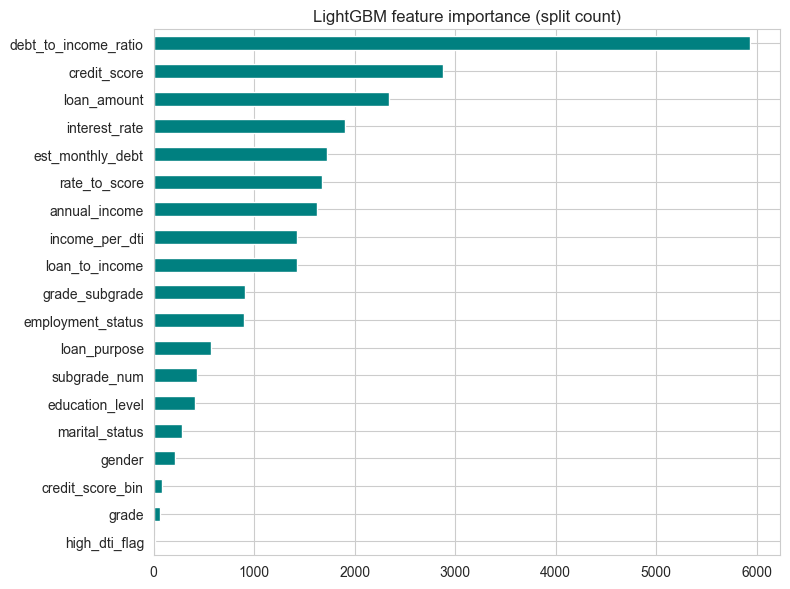

In [19]:
fig, ax = plt.subplots(figsize=(8, 6))
importances = pd.Series(final_model.feature_importances_, index=feature_cols).sort_values()
importances.plot(kind="barh", ax=ax, color="teal")
ax.set_title("LightGBM feature importance (split count)")
plt.tight_layout()
plt.show()

In [20]:
print("Link: https://www.kaggle.com/competitions/playground-series-s5e11/overview")

Link: https://www.kaggle.com/competitions/playground-series-s5e11/overview
